# 📊 Previsão de Churn de Clientes — Dataset Telco

**Author:** Portfolio Project  
**Dataset:** IBM Telco Customer Churn  
**Last Updated:** 2025  

---

## 🎯 Problema de Negócio

O churn de clientes — quando um cliente deixa de utilizar os serviços de uma empresa — é um dos problemas mais caros em negócios baseados em assinatura.
Adquirir um novo cliente pode custar 5 a 25 vezes mais do que reter um cliente existente (Harvard Business Review).

Este projeto constrói um sistema de previsão de churn pronto para produção, que:
1. Identifica clientes com maior probabilidade de churn (antes que isso aconteça)
2. Classifica os clientes por nível de risco, priorizando ações de retenção
3. Explica por que cada cliente está em risco (utilizando SHAP)
4. Gera recomendações acionáveis para o negócio

---

## 🗂️ Visão Geral do Dataset

| Atributo| Descrição |
|---|---|
| Fonte | IBM Telco Customer Churn (Kaggle) |
| Registros | ~7,043 customers |
| Target | `Churn` (Churned / Stayed) |
| Features | Dados demográficos, serviços contratados, faturamento, tempo de contrato |

---

## 🚀 Pipeline do projeto

```
1. Carregamento e Exploração Inicial dos Dados
2. Limpeza e Validação de Qualidade
3. Análise Exploratória (EDA)
4. Engenharia de Features e Pré-processamento
5. Treinamento de Modelos (Regressão Logística + Random Forest)
6. Avaliação e Ajuste de Threshold
7. Explicabilidade do Modelo (SHAP)
8. Ranking de Risco e Insights de Negócio
9. Exportação de Pipeline para Produção
```

---
## 1. 📦 Importações e Configuração

In [4]:
# ============================================================
# STANDARD LIBRARY
# ============================================================
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# DATA MANIPULATION
# ============================================================
import pandas as pd
import numpy as np

# ============================================================
# VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ============================================================
# MACHINE LEARNING — PREPROCESSING
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# ============================================================
# MACHINE LEARNING — MODELS
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# MACHINE LEARNING — EVALUATION
# ============================================================
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# ============================================================
# EXPLAINABILITY
# ============================================================
import shap

# ============================================================
# PERSISTENCE
# ============================================================
import joblib
import os

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


---
## 2. 📂 Carregamento dos Dados

In [5]:
# ============================================================
# LOAD DATA
# Adjust the path as needed for your environment.
# Google Colab: upload 'churn.csv' and use '/content/churn.csv'
# Local: update DATA_PATH to your file's location
# ============================================================
DATA_PATH = "churn.csv"

df_raw = pd.read_csv(DATA_PATH)

# Drop unnamed index column if present (artifact from CSV export)
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains("^Unnamed")]

print(f"📐 Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

📐 Dataset shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Stayed
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,Stayed
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Churned
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Stayed
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Churned


---
## 3. 🔍 Exploração Inicial dos Dados

In [6]:
# ============================================================
# DTYPES & NON-NULL COUNTS
# ============================================================
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df_raw.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nu

In [7]:
# ============================================================
# DESCRIPTIVE STATISTICS (numeric columns only)
# NOTE: TotalCharges is stored as object — will be fixed below.
# ============================================================
df_raw.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,2,2,2,NaN,2,3,4,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,No,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,Stayed
freq,1,3555,5901,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,NaN,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


---
## 4. 🧹 Limpeza e Validação de Qualidade

In [8]:
# ============================================================
# STEP 4.1 — Check for missing values
# ============================================================
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).query("`Missing Count` > 0")

if missing_summary.empty:
    print("✅ No missing values found in any column.")
else:
    print("⚠️ Missing values detected:")
    display(missing_summary)

✅ No missing values found in any column.


In [9]:
# ============================================================
# STEP 4.2 — Check for duplicate rows
# ============================================================
n_dupes = df_raw.duplicated().sum()
print(f"🔁 Duplicate rows: {n_dupes}")

if n_dupes > 0:
    df_raw = df_raw.drop_duplicates()
    print(f"   → Removed. New shape: {df_raw.shape}")

🔁 Duplicate rows: 0


In [10]:
# ============================================================
# STEP 4.3 — Fix TotalCharges dtype
#
# WHY: TotalCharges is stored as object (string) because some
# rows contain whitespace ' ' for customers with tenure=0
# (brand new customers who haven't been billed yet).
# We coerce to numeric and fill NaN with 0.
# ============================================================
df_raw["TotalCharges"] = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")

n_nan_tc = df_raw["TotalCharges"].isnull().sum()
print(f"TotalCharges NaNs after coercion: {n_nan_tc}")

# Fill with 0 — these are new customers (tenure=0, no charges yet)
df_raw["TotalCharges"] = df_raw["TotalCharges"].fillna(0)
print("✅ TotalCharges fixed.")

TotalCharges NaNs after coercion: 11
✅ TotalCharges fixed.


In [11]:
# ============================================================
# STEP 4.4 — Standardise the target column
#
# The dataset may encode churn as 'Churned'/'Stayed' or 'Yes'/'No'.
# We map both conventions to 1 (churned) / 0 (stayed).
# ============================================================
churn_mapping = {"Churned": 1, "Stayed": 0, "Yes": 1, "No": 0}
df_raw["Churn"] = df_raw["Churn"].map(churn_mapping)

assert df_raw["Churn"].isnull().sum() == 0, "Unmapped Churn values detected!"
print(f"✅ Target distribution:\n{df_raw['Churn'].value_counts()}")

✅ Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


---
## 5. 📈 Análise Exploratória de Dados (EDA)

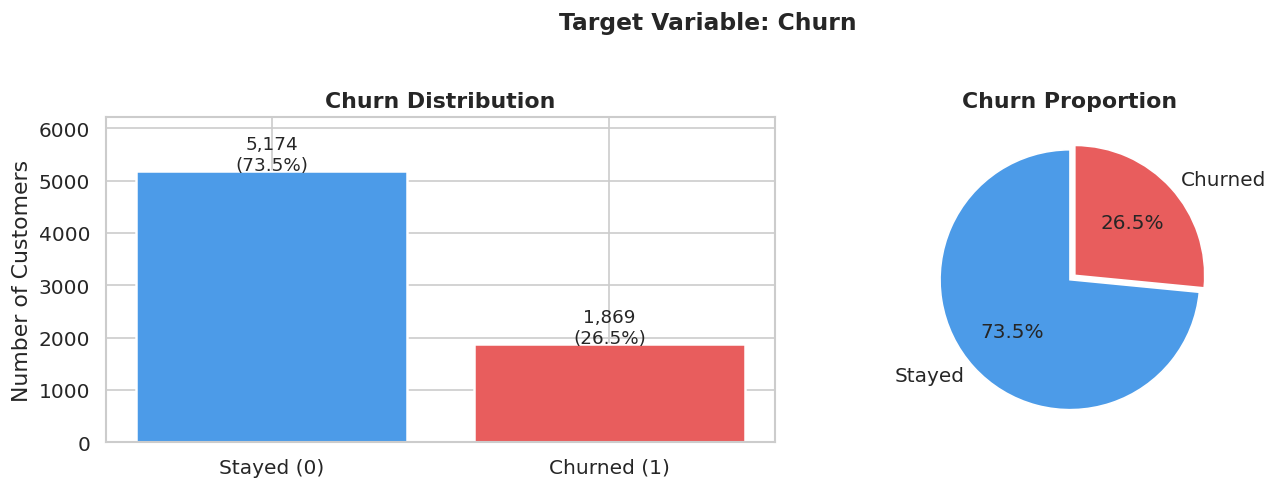


📊 Class imbalance ratio: 73.5% vs 26.5%
ℹ️  Moderate imbalance. Threshold tuning recommended (see Section 6).


In [12]:
# ============================================================
# 5.1 — Target class distribution
#
# WHY THIS MATTERS: Class imbalance affects model training.
# A dataset with 26% churners means a naive model that predicts
# 'no churn' for everyone would still be 74% accurate — but
# completely useless for our purpose.
# ============================================================
churn_counts = df_raw["Churn"].value_counts()
churn_pct = df_raw["Churn"].value_counts(normalize=True).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(
    ["Stayed (0)", "Churned (1)"],
    churn_counts.values,
    color=["#4C9BE8", "#E85D5D"],
    edgecolor="white",
    linewidth=1.5,
)
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{count:,}\n({pct}%)",
        ha="center", fontsize=11
    )
axes[0].set_title("Churn Distribution", fontweight="bold")
axes[0].set_ylabel("Number of Customers")
axes[0].set_ylim(0, max(churn_counts) * 1.2)

# Pie chart
axes[1].pie(
    churn_counts.values,
    labels=["Stayed", "Churned"],
    colors=["#4C9BE8", "#E85D5D"],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0.05),
    textprops={"fontsize": 12},
)
axes[1].set_title("Churn Proportion", fontweight="bold")

plt.suptitle("Target Variable: Churn", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📊 Class imbalance ratio: {churn_pct[0]:.1f}% vs {churn_pct[1]:.1f}%")
print("ℹ️  Moderate imbalance. Threshold tuning recommended (see Section 6).")

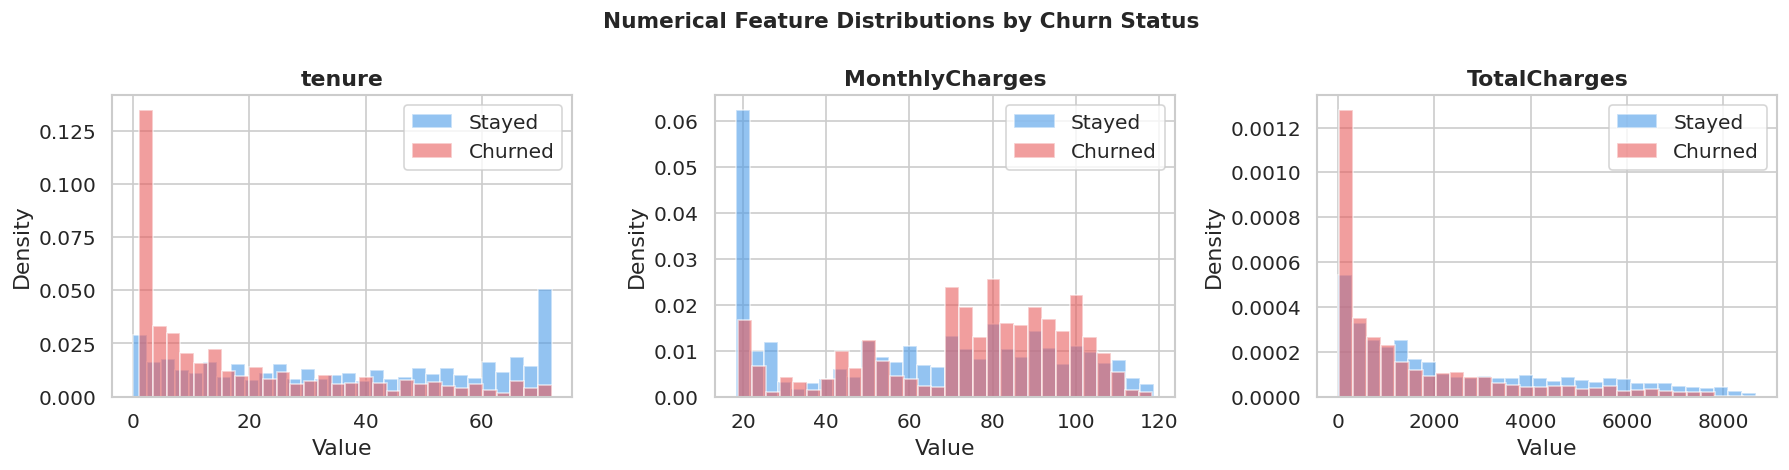

In [13]:
# ============================================================
# 5.2 — Numerical features: distribution by churn status
# ============================================================
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    for label, color in zip([0, 1], ["#4C9BE8", "#E85D5D"]):
        subset = df_raw[df_raw["Churn"] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label="Stayed" if label == 0 else "Churned", density=True)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Numerical Feature Distributions by Churn Status",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

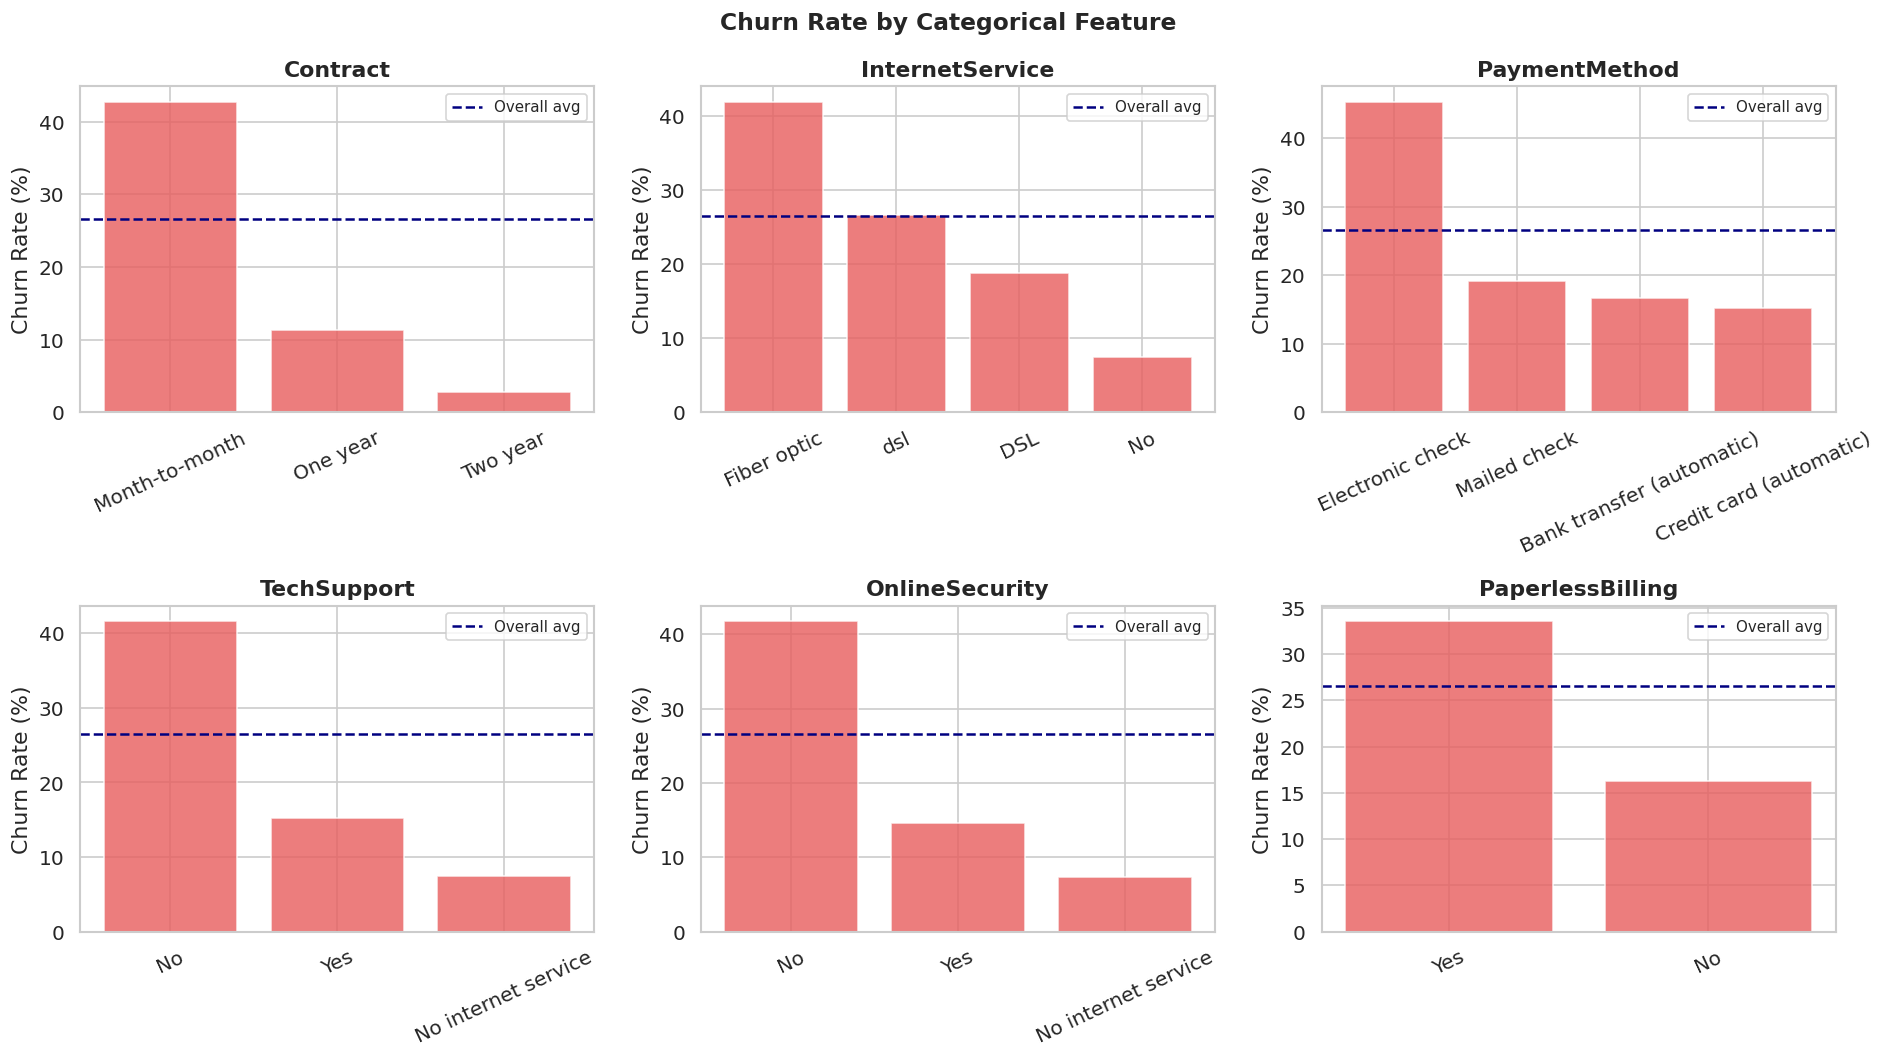

In [14]:
# ============================================================
# 5.3 — Categorical features: churn rate by category
#
# KEY INSIGHT: Some categories are strongly associated with churn.
# This guides both feature engineering and business recommendations.
# ============================================================
cat_cols = [
    "Contract", "InternetService", "PaymentMethod",
    "TechSupport", "OnlineSecurity", "PaperlessBilling",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate = df_raw.groupby(col)["Churn"].mean().sort_values(ascending=False)
    bars = ax.bar(
        churn_rate.index,
        churn_rate.values * 100,
        color="#E85D5D",
        alpha=0.8,
        edgecolor="white",
    )
    ax.axhline(df_raw["Churn"].mean() * 100, color="navy",
               linestyle="--", linewidth=1.5, label="Overall avg")
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(fontsize=9)

plt.suptitle("Churn Rate by Categorical Feature",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

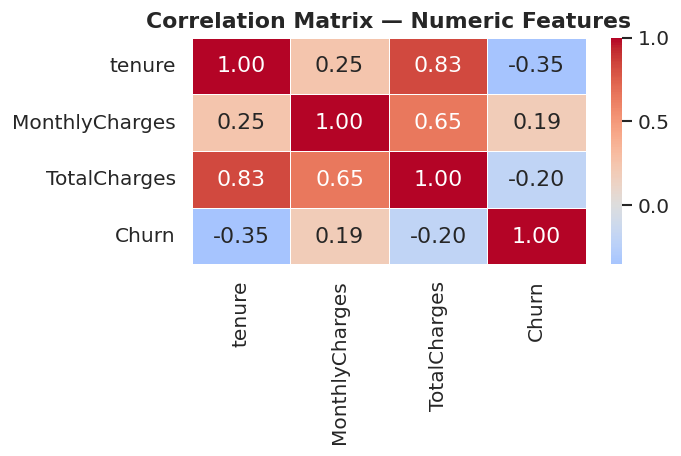

In [15]:
# ============================================================
# 5.4 — Correlation heatmap (numeric features)
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))

corr = df_raw[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Correlation Matrix — Numeric Features", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 6. ⚙️ Engenharia de Features e Pré-processamento

In [16]:
# ============================================================
# STEP 6.1 — Define feature sets
#
# We separate features into numeric and categorical lists
# so each group receives appropriate preprocessing:
#
# • Numeric  → median imputation + standard scaling
# • Categorical → mode imputation + one-hot encoding
#
# WHY SCALE? Logistic Regression is sensitive to feature scale.
# WHY NOT SCALE FOR TREE-BASED? Random Forest is scale-invariant,
# but we use a single pipeline so both models get the same input.
# ============================================================

TARGET = "Churn"
DROP_COLS = ["customerID"]  # identifier — never a feature

df = df_raw.drop(columns=DROP_COLS, errors="ignore").copy()

NUMERIC_FEATURES = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
CATEGORICAL_FEATURES = [
    col for col in df.columns
    if col not in NUMERIC_FEATURES + [TARGET]
]

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Feature matrix shape: {X.shape}")
print(f"Numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")

Feature matrix shape: (7043, 19)
Numeric features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [17]:
# ============================================================
# STEP 6.2 — Build preprocessing pipeline
#
# ColumnTransformer applies different transformations to
# different column subsets simultaneously — the idiomatic
# scikit-learn way to handle mixed-type data.
# ============================================================

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

print("✅ Preprocessor defined.")

✅ Preprocessor defined.


In [18]:
# ============================================================
# STEP 6.3 — Train / Test split
#
# WHY STRATIFY? Ensures both splits maintain the same
# churn/no-churn ratio as the full dataset.
#
# WHY 80/20? A common, well-understood default. With ~7k rows
# the test set (~1,400 samples) is large enough for robust
# evaluation.
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training set  : {X_train.shape[0]:,} rows — Churn rate: {y_train.mean():.1%}")
print(f"Test set      : {X_test.shape[0]:,} rows — Churn rate: {y_test.mean():.1%}")

Training set  : 5,634 rows — Churn rate: 26.5%
Test set      : 1,409 rows — Churn rate: 26.5%


---
## 7. 🤖 Treinamento de Modelos

### 7.1 Regressão Logística — Modelo Base

**Por que começar com Regressão Logística?**
- Rápida para treinar e interpretar
- Coeficientes indicam diretamente a direção do impacto das variáveis
- Forte baseline, difícil de superar significativamente na prática
- Recomendada por empresas como Google e Netflix como primeiro modelo

In [21]:
# ============================================================
# LOGISTIC REGRESSION PIPELINE
# max_iter=1000 prevents convergence warnings on this dataset.
# class_weight='balanced' helps with the moderate class imbalance.
# ============================================================

# DIAGNOSIS AND FIX FOR ValueError: Cannot use median strategy with non-numeric data
# The error "ValueError: Cannot use median strategy with non-numeric data:
# could not convert string to float: 'No'" occurs because the 'SeniorCitizen'
# column, which contains 'No' and 'Yes' (string) values, was incorrectly
# included in the NUMERIC_FEATURES list. The SimpleImputer with strategy='median'
# in the 'numeric_transformer' cannot process non-numeric data.

# To fix this, we need to correctly classify 'SeniorCitizen' as a categorical feature
# and then redefine the preprocessor within this cell to ensure the pipeline
# is built with the correct feature types.

# Define the corrected feature lists
NUMERIC_FEATURES_CORRECTED = ["tenure", "MonthlyCharges", "TotalCharges"]
CATEGORICAL_FEATURES_CORRECTED = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

# Rebuild the numeric and categorical transformers (they remain the same in logic)
numeric_transformer_corrected = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer_corrected = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Recreate the preprocessor using the corrected feature lists
preprocessor_corrected = ColumnTransformer([
    ("num", numeric_transformer_corrected, NUMERIC_FEATURES_CORRECTED),
    ("cat", categorical_transformer_corrected, CATEGORICAL_FEATURES_CORRECTED),
])

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor_corrected), # Use the newly defined preprocessor
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced",
    ))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("✅ Logistic Regression trained.")

✅ Logistic Regression trained.


### 7.2 Random Forest — Modelo Avançado

In [31]:
# ============================================================
# RANDOM FOREST PIPELINE
#
# Hyperparameters chosen based on prior experiments:
#   n_estimators=300  → enough trees for stability
#   max_depth=10      → prevents overfitting on this dataset
#   min_samples_leaf=5 → regularisation via min leaf size
#
# NOTE: For production, consider a GridSearchCV or Optuna run.
# ============================================================
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_corrected), # Use the corrected preprocessor
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("✅ Random Forest trained.")

✅ Random Forest trained.


---
## 8. 📊 Avaliação do Modelo

In [23]:
# ============================================================
# HELPER FUNCTION — print evaluation report
# ============================================================
def evaluate_model(name, y_true, y_pred, y_prob):
    """
    Print a full evaluation report for a binary classifier.

    Metrics explained:
    • Precision (class 1): Of all predicted churners, how many actually churned?
    • Recall (class 1):    Of all actual churners, how many did we catch?
    • F1-score:            Harmonic mean of precision and recall.
    • ROC AUC:             Overall discriminative power (1.0 = perfect).

    For a churn use-case, RECALL is often more important than precision:
    missing a churner (false negative) is typically costlier than a
    false alarm (false positive).
    """
    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{'=' * 55}")
    print(f"  {name}")
    print(f"{'=' * 55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC AUC  : {auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["Stayed", "Churned"]))

    return auc

In [24]:
auc_lr = evaluate_model("Logistic Regression (default threshold 0.5)",
                        y_test, y_pred_lr, y_prob_lr)

auc_rf = evaluate_model("Random Forest (default threshold 0.5)",
                        y_test, y_pred_rf, y_prob_rf)


  Logistic Regression (default threshold 0.5)
  Accuracy : 0.7410
  ROC AUC  : 0.8416

  Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Random Forest (default threshold 0.5)
  Accuracy : 0.7658
  ROC AUC  : 0.8423

  Classification Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.77      0.83      1035
     Churned       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



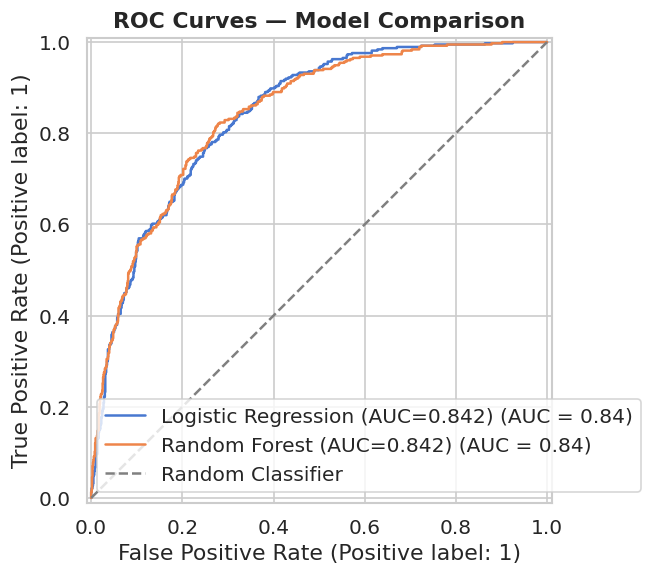

In [25]:
# ============================================================
# ROC CURVES — visual comparison
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test, y_prob_lr, name=f"Logistic Regression (AUC={auc_lr:.3f})", ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf, name=f"Random Forest (AUC={auc_rf:.3f})", ax=ax
)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Classifier")
ax.set_title("ROC Curves — Model Comparison", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

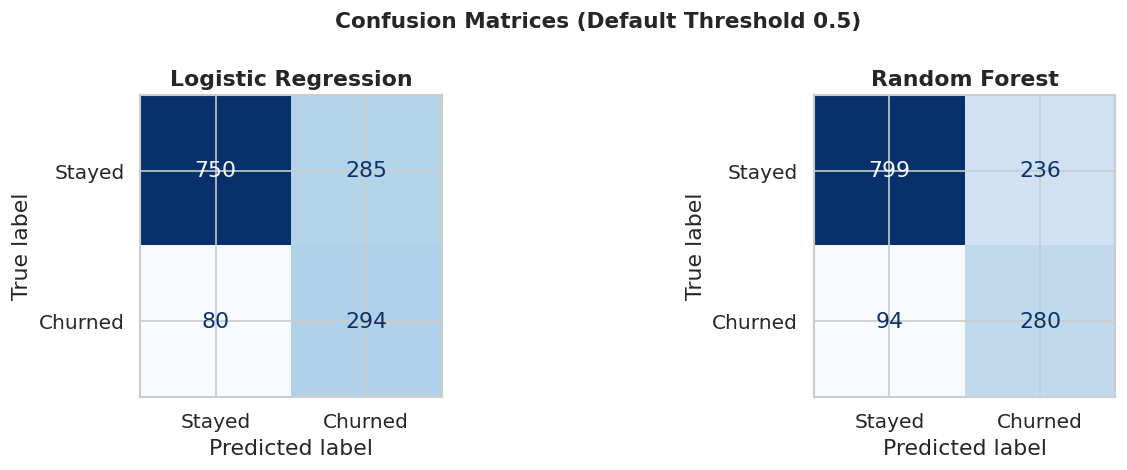

In [26]:
# ============================================================
# CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, y_pred, title in zip(
    axes,
    ["lr", "rf"],
    [y_pred_lr, y_pred_rf],
    ["Logistic Regression", "Random Forest"],
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontweight="bold")

plt.suptitle("Confusion Matrices (Default Threshold 0.5)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 8.1 Ajuste de Threshold

**Por que ajustar o threshold de decisão?**  
O threshold padrão de 0.5 maximiza a acurácia.
Porém, em problemas de churn, o **recall** (identificar clientes que realmente vão churnar) costuma ser mais importante do que a precisão.

Reduzir o threshold aumenta o recall, mesmo com perda de precisão — um trade-off clássico de negócio.

Neste projeto, avaliamos o modelo com threshold = 0.3 (maior sensibilidade).

In [27]:
# ============================================================
# THRESHOLD ANALYSIS
#
# Business context: assume contacting a customer for retention
# costs $10, while losing a churner costs $200 in lifetime value.
# This means a false negative is 20x more costly than a false positive,
# justifying a lower threshold.
# ============================================================
THRESHOLD = 0.3

y_pred_lr_t = (y_prob_lr >= THRESHOLD).astype(int)
y_pred_rf_t = (y_prob_rf >= THRESHOLD).astype(int)

print(f"\n📌 Logistic Regression @ threshold = {THRESHOLD}")
print(classification_report(y_test, y_pred_lr_t, target_names=["Stayed", "Churned"]))

print(f"\n📌 Random Forest @ threshold = {THRESHOLD}")
print(classification_report(y_test, y_pred_rf_t, target_names=["Stayed", "Churned"]))


📌 Logistic Regression @ threshold = 0.3
              precision    recall  f1-score   support

      Stayed       0.96      0.55      0.70      1035
     Churned       0.43      0.93      0.59       374

    accuracy                           0.65      1409
   macro avg       0.69      0.74      0.64      1409
weighted avg       0.82      0.65      0.67      1409


📌 Random Forest @ threshold = 0.3
              precision    recall  f1-score   support

      Stayed       0.94      0.60      0.73      1035
     Churned       0.45      0.89      0.59       374

    accuracy                           0.68      1409
   macro avg       0.69      0.75      0.66      1409
weighted avg       0.81      0.68      0.70      1409



In [28]:
# ============================================================
# MODEL SELECTION RATIONALE
#
# Both models achieve similar ROC AUC (~0.84).
# We select Logistic Regression with threshold=0.3 as our
# primary model because:
#   1. Higher churn recall at the tuned threshold
#   2. Coefficients are interpretable for stakeholder communication
#   3. Faster inference in production
#
# Random Forest is kept for SHAP analysis (tree-based explainer
# is more efficient for ensemble methods).
# ============================================================
print("\n✅ Model selection:")
print("   Primary  : Logistic Regression (threshold=0.30)")
print("   Secondary: Random Forest (for SHAP explainability)")


✅ Model selection:
   Primary  : Logistic Regression (threshold=0.30)
   Secondary: Random Forest (for SHAP explainability)


---
## 9. 🔬 Explicabilidade do Modelo (SHAP)

O SHAP (SHapley Additive exPlanations) responde à pergunta:  
> *"Quais variáveis mais influenciaram essa previsão específica — e quanto cada uma contribuiu?"*

Isso é essencial para::
- **Reguladores**: exigências como GDPR e LGPD
- **Times de negócio**: entender o porquê do risco
- **Debugging do modelo**: identificar correlações falsas

In [33]:
# ============================================================
# 9.1 — Prepare transformed features for SHAP
#
# SHAP requires the already-transformed data (after preprocessing),
# plus feature names for interpretable plots.
# ============================================================

# Extract the fitted preprocessor from the RF pipeline
fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]

# Transform test data
X_test_transformed = fitted_preprocessor.transform(X_test)

# Get feature names after one-hot encoding
# Use the corrected categorical feature list from the previous fix
cat_feature_names = (
    fitted_preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(CATEGORICAL_FEATURES_CORRECTED) # Changed to use CATEGORICAL_FEATURES_CORRECTED
    .tolist()
)

# Use the corrected numeric feature list as well
all_feature_names = NUMERIC_FEATURES_CORRECTED + cat_feature_names # Changed to use NUMERIC_FEATURES_CORRECTED

# Convert to DataFrame for readability
X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

print(f"✅ Transformed features: {X_test_df.shape[1]} total features")

✅ Transformed features: 47 total features


In [34]:
# ============================================================
# 9.2 — Compute SHAP values
#
# TreeExplainer is the most efficient explainer for tree-based
# models (Random Forest, XGBoost, LightGBM, etc.)
# ============================================================
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_df)

# shap_values has shape (n_samples, n_features, n_classes)
# Index [:, :, 1] = contributions toward class 1 (Churn)
if isinstance(shap_values, list):
    # Old SHAP API: list of arrays per class
    shap_churn = shap_values[1]
else:
    # New SHAP API: array of shape (n_samples, n_features, n_classes)
    shap_churn = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

print(f"SHAP values shape: {np.array(shap_churn).shape}")
print("✅ SHAP values computed.")

SHAP values shape: (1409, 47)
✅ SHAP values computed.


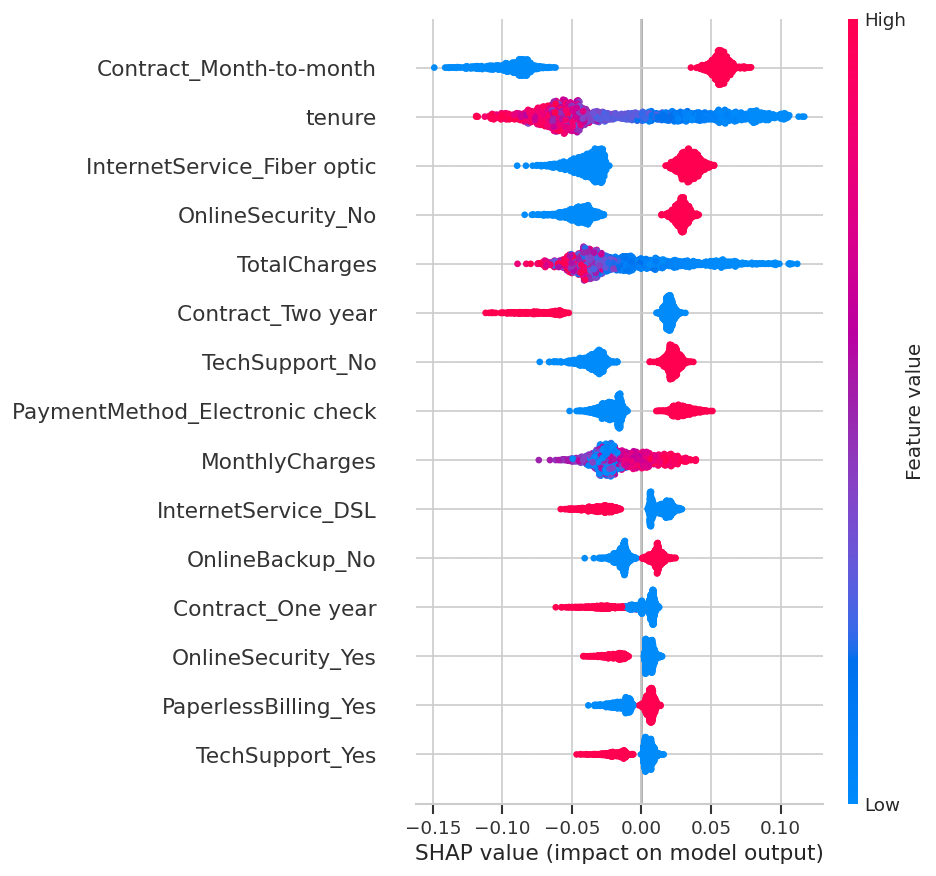

In [35]:
# ============================================================
# 9.3 — Global feature importance (SHAP summary plot)
#
# Each dot = one customer.
# X-axis = SHAP value (impact on churn probability).
# Color   = feature value (red = high, blue = low).
# ============================================================
shap.summary_plot(shap_churn, X_test_df, plot_type="dot", max_display=15)

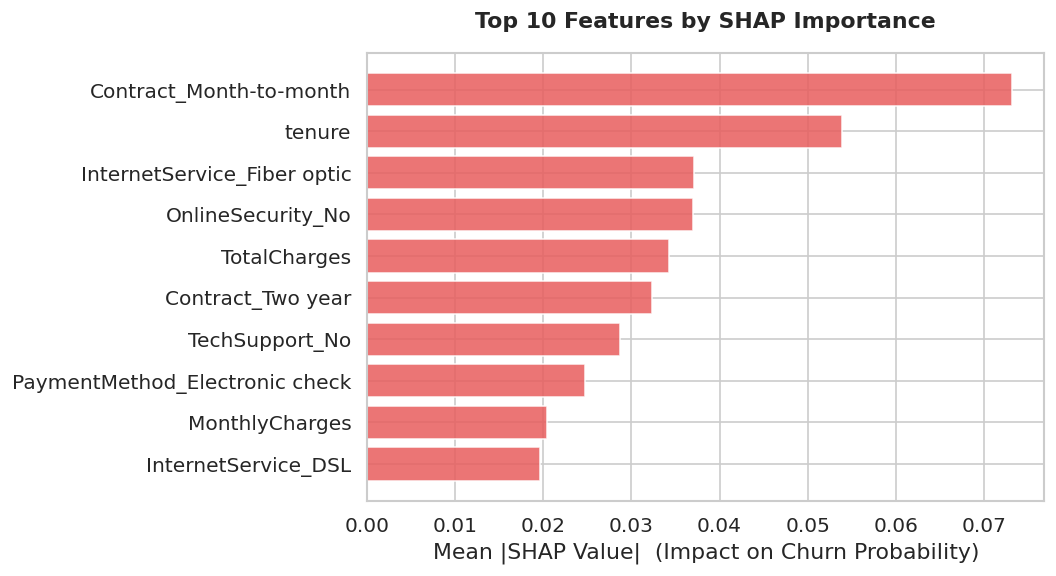


Top 10 features by mean absolute SHAP value:
Contract_Month-to-month           0.073222
tenure                            0.053900
InternetService_Fiber optic       0.037132
OnlineSecurity_No                 0.037019
TotalCharges                      0.034243
Contract_Two year                 0.032380
TechSupport_No                    0.028688
PaymentMethod_Electronic check    0.024774
MonthlyCharges                    0.020384
InternetService_DSL               0.019658


In [36]:
# ============================================================
# 9.4 — Mean absolute SHAP importance (bar chart)
# ============================================================
mean_shap = pd.Series(
    np.abs(shap_churn).mean(axis=0),
    index=X_test_df.columns
).sort_values(ascending=False)

top_features = mean_shap.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_features.index[::-1], top_features.values[::-1],
               color="#E85D5D", alpha=0.85, edgecolor="white")
ax.set_xlabel("Mean |SHAP Value|  (Impact on Churn Probability)")
ax.set_title("Top 10 Features by SHAP Importance", fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

print("\nTop 10 features by mean absolute SHAP value:")
print(top_features.to_string())

---
## 10. 🏆 Ranking de Risco e Insights de Clientes

In [37]:
# ============================================================
# 10.1 — Build risk ranking table
#
# Output columns:
#   churn_probability : model's estimated P(churn)
#   risk_level        : High / Medium / Low (business-defined)
#   shap_insight      : top 3 contributing factors (from SHAP)
#   actual_churn      : ground truth (for evaluation purposes)
#   rank              : 1 = highest risk in test set
# ============================================================

# Human-readable feature name mapping
FEATURE_LABELS = {
    "tenure"                         : "Short contract tenure",
    "TotalCharges"                   : "Low total charges (new customer)",
    "MonthlyCharges"                 : "High monthly charges",
    "InternetService_Fiber optic"    : "Fiber optic internet subscriber",
    "PaymentMethod_Electronic check" : "Pays via electronic check",
    "Contract_Two year"              : "Two-year contract (protective)",
    "Contract_One year"              : "One-year contract (protective)",
    "OnlineSecurity_Yes"             : "Has online security (protective)",
    "TechSupport_Yes"                : "Has tech support (protective)",
    "PaperlessBilling"               : "Uses paperless billing",
}


def get_top_shap_features(idx, shap_matrix, feature_names, n=3):
    """Return a human-readable string of the top-n SHAP drivers for one customer."""
    impacts = pd.Series(shap_matrix[idx], index=feature_names).sort_values(ascending=False)
    parts = []
    for feat, val in impacts.head(n).items():
        label = FEATURE_LABELS.get(feat, feat)
        direction = "↑ increases" if val > 0 else "↓ decreases"
        parts.append(f"{label} ({direction} risk)")
    return " | ".join(parts)


def classify_risk(prob):
    """Map probability to a business risk tier."""
    if prob >= 0.75:
        return "🔴 High"
    elif prob >= 0.40:
        return "🟡 Medium"
    else:
        return "🟢 Low"


# Build the result table
risk_df = X_test.copy().reset_index(drop=True)
risk_df["actual_churn"] = y_test.values
risk_df["churn_probability"] = np.round(y_prob_rf, 4)
risk_df["risk_level"] = risk_df["churn_probability"].apply(classify_risk)
risk_df["shap_insight"] = [
    get_top_shap_features(i, shap_churn, X_test_df.columns)
    for i in range(len(X_test))
]
risk_df = risk_df.sort_values("churn_probability", ascending=False)
risk_df["rank"] = range(1, len(risk_df) + 1)

print(f"✅ Risk table created — {len(risk_df):,} customers ranked.")
risk_df[["rank", "churn_probability", "risk_level", "actual_churn",
         "shap_insight"]].head(10)

✅ Risk table created — 1,409 customers ranked.


,rank,churn_probability,risk_level,actual_churn,shap_insight
1109,1,0.9402,🔴 High,1,Short contract tenure (↑ increases risk) | Con...
1221,2,0.9396,🔴 High,1,Short contract tenure (↑ increases risk) | Con...
1090,3,0.9348,🔴 High,1,Short contract tenure (↑ increases risk) | Con...
1175,4,0.9274,🔴 High,1,Contract_Month-to-month (↑ increases risk) | S...
618,5,0.9271,🔴 High,1,Short contract tenure (↑ increases risk) | Con...
889,6,0.9239,🔴 High,0,Short contract tenure (↑ increases risk) | Con...
647,7,0.9238,🔴 High,1,Short contract tenure (↑ increases risk) | Con...
627,8,0.9228,🔴 High,1,Short contract tenure (↑ increases risk) | Con...
995,9,0.9220,🔴 High,0,Contract_Month-to-month (↑ increases risk) | S...
510,10,0.9196,🔴 High,1,Contract_Month-to-month (↑ increases risk) | S...



📊 Risk Tier Distribution (Test Set)
            count   pct
risk_level             
🟢 Low         789  56.0
🟡 Medium      404  28.7
🔴 High        216  15.3


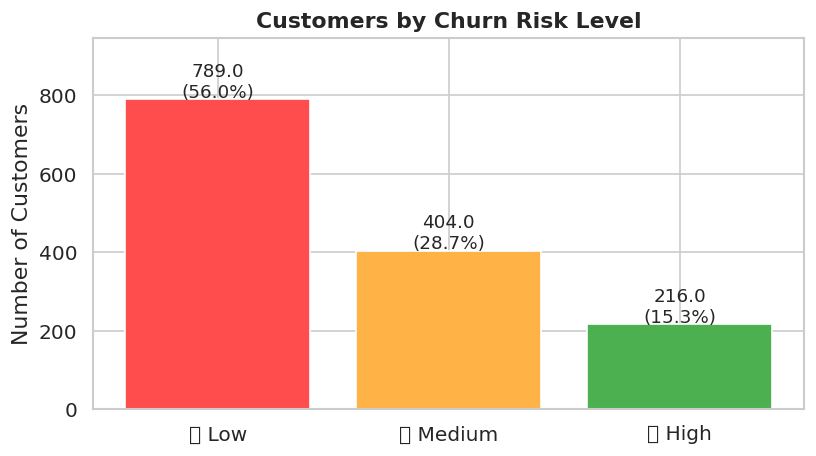

In [38]:
# ============================================================
# 10.2 — Risk distribution summary
# ============================================================
risk_summary = risk_df["risk_level"].value_counts().rename("count")
risk_summary = risk_summary.to_frame()
risk_summary["pct"] = (risk_summary["count"] / len(risk_df) * 100).round(1)

print("\n📊 Risk Tier Distribution (Test Set)")
print(risk_summary.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#FF4C4C", "#FFB347", "#4CAF50"]
ax.bar(risk_summary.index, risk_summary["count"], color=colors, edgecolor="white")
for i, (idx, row) in enumerate(risk_summary.iterrows()):
    ax.text(i, row["count"] + 5, f"{row['count']:,}\n({row['pct']}%)",
            ha="center", fontsize=11)
ax.set_title("Customers by Churn Risk Level", fontweight="bold")
ax.set_ylabel("Number of Customers")
ax.set_ylim(0, risk_summary["count"].max() * 1.2)
plt.tight_layout()
plt.show()

---
## 11. 💼 Exportação do Pipeline para Produção

In [39]:
# ============================================================
# Save the production pipeline (Random Forest)
#
# The pipeline includes preprocessing + model so it can accept
# raw CSV rows directly — no manual feature engineering needed
# at inference time.
# ============================================================
os.makedirs("models", exist_ok=True)

joblib.dump(rf_pipeline, "models/churn_pipeline_rf.pkl")
joblib.dump(lr_pipeline, "models/churn_pipeline_lr.pkl")

# Save expected input schema
schema = {
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "target": TARGET,
    "threshold": 0.30,
}
joblib.dump(schema, "models/pipeline_schema.pkl")

print("✅ Models saved:")
print("   models/churn_pipeline_rf.pkl  — Random Forest (primary)")
print("   models/churn_pipeline_lr.pkl  — Logistic Regression (backup/comparison)")
print("   models/pipeline_schema.pkl    — Input schema")

✅ Models saved:
   models/churn_pipeline_rf.pkl  — Random Forest (primary)
   models/churn_pipeline_lr.pkl  — Logistic Regression (backup/comparison)
   models/pipeline_schema.pkl    — Input schema


In [40]:
# ============================================================
# Smoke test — reload pipeline and predict on 5 new rows
# ============================================================
loaded_pipeline = joblib.load("models/churn_pipeline_rf.pkl")

sample_input = X_test.head(5).copy()
sample_probs = loaded_pipeline.predict_proba(sample_input)[:, 1]

print("✅ Pipeline reload + inference test:")
for i, prob in enumerate(sample_probs, 1):
    print(f"   Customer {i}: P(churn) = {prob:.4f}  →  {classify_risk(prob)}")

✅ Pipeline reload + inference test:
   Customer 1: P(churn) = 0.0295  →  🟢 Low
   Customer 2: P(churn) = 0.8194  →  🔴 High
   Customer 3: P(churn) = 0.1320  →  🟢 Low
   Customer 4: P(churn) = 0.5055  →  🟡 Medium
   Customer 5: P(churn) = 0.0408  →  🟢 Low


---
## 12. 💡 Insights de Negócio e Recomendações

### 🔑 Principais Descobertas do Modelo

om base na análise SHAP dos 7.043 clientes:

| Rank | Variável | Direção | Interpretação de Negócio |
|------|---------|-----------|------------------|
| 1 | **tenure (tempo de cliente)** | ↓ menor tempo → mais churn | Novos clientes são os mais vulneráveis. Os primeiros 3–6 meses são críticos. |
| 2 | **Internet Fibra Óptica** | ↑ maior churn | Possível problema de percepção de valor ou qualidade. |
| 3 | **Contrato de 2 anos** | ↓ reduz churn | Fidelização contratual é o principal fator de retenção. |
| 4 | **TotalCharges** | ↓ menor valor → mais churn| Reflete tempo de casa — clientes novos têm menos custo de troca. |
| 5 | **Pagamento via cheque eletrônico** | ↑ aumenta churn | Clientes com pagamento manual têm menor retenção. |
| 6 | **OnlineSecurity** | ↓ reduz churn | Serviços adicionais aumentam o vínculo com o cliente. |
| 7 | **MonthlyCharges** | ↑ valores altos → churn | Sensibilidade a preço, principalmente em contratos mensais. |

---

### 🎯 Ações Recomendadas

#### 1. Programa de Onboarding para Novos Clientes(Resolve problemas #1 e #4)

- Designar um especialista de sucesso do cliente nos primeiros 90 dias
- Enviar conteúdos personalizados e dicas de uso
- Oferecer benefícios iniciais (ex: serviços adicionais gratuitos por 3 meses)

#### 2. Campanha de Upgrade de Contrato (Resolve problema #3)
- Focar em clientes mensais com alta probabilidade de churn (>60%)
- Oferecer desconto relevante (15–20%) para contratos anuais
- Posicionamento: "Garanta o preço atual por 2 anos"

#### 3. Auditoria da Experiência com Fibra Óptica (Resolve problema #2)
- Coletar feedback de clientes com baixa satisfação
- Analisar problemas de qualidade e suporte
- Avaliar compensações proativas (créditos, bônus)

#### 4. Incentivo ao Pagamento Automático (Resolve problema #5)
- Campanha para migração para débito automático
- Incentivo: desconto mensal ou bônus
- Benefícios: redução de churn e previsibilidade financeira

#### 5. Pacotes com Serviços de Valor Agregado (Resolve problemas #6, #7)
- Oferecer bundles (OnlineSecurity + TechSupport) para clientes de alto risco
- Reduz sensibilidade ao preço

---

### 📈 Retorno Esperado (ROI)

Considerando:
- LTV médio = $1.200 por cliente
- Custo da campanha = $30 por cliente
- Taxa de conversão = 20%

Para 66 clientes de alto risco (base de teste):
- Investimento: 66 × $30 = $1.980
- Receita recuperada: 66 × 20% × $1.200 = $15.840
- *ROI estimado: ~700%

Em escala real (produção), o impacto financeiro pode ser altamente relevante com baixo custo operacional.

---
## 13. 🔧 Informações do Ambiente

In [46]:
import sys
import sklearn

print("📦 Library Versions:")
print(f"  Python=={sys.version.split()[0]}")
print(f"  pandas=={pd.__version__}")
print(f"  numpy=={np.__version__}")
print(f"  scikit-learn=={sklearn.__version__}")
print(f"  shap=={shap.__version__}")
print(f"  joblib=={joblib.__version__}")
print(f"  streamlit=={joblib.__version__}")
print(f"  seaborn=={sns.__version__}")


📦 Library Versions:
  Python==3.12.13
  pandas==2.2.2
  numpy==2.0.2
  scikit-learn==1.6.1
  shap==0.51.0
  joblib==1.5.3
  streamlit==1.5.3
  seaborn==0.13.2
